In [1]:
# This cell imports the libraries needed for raw dataset inspection and visualization.
# It prepares utilities for counting labels, plotting charts, and loading torchvision datasets.
# These imports are shared across the MNIST, C-MNIST, and STL-10 sections.
import random
from collections import Counter
import numpy as np 
import matplotlib.pyplot as plt
from torchvision import datasets

In [2]:
# This helper plots class-count distributions for one or more dataset splits.
# It is reused later to compare train and test label balance across all datasets.
# The chart layout automatically adapts to the number of splits provided.
def plot_class_distribution(split_names, split_counts, class_labels, title):
    num_classes = len(class_labels)
    num_splits = len(split_names)
    x_positions = np.arange(num_classes)
    bar_width = 0.8 / num_splits

    plt.figure(figsize=(12, 5))

    for split_index, (split_name, counts) in enumerate(zip(split_names, split_counts)):
        offset = (split_index - (num_splits - 1) / 2) * bar_width
        plt.bar(x_positions + offset, counts, width=bar_width, label=split_name)

    plt.xticks(x_positions, class_labels, rotation=30 if any(len(str(label)) > 3 for label in class_labels) else 0)
    plt.xlabel("Class")
    plt.ylabel("Number of Samples")
    plt.title(title)
    plt.legend()
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()


# MNIST
Raw dataset loading, class inspection, distribution check, and image visualization for standard MNIST.

In [3]:
# This cell defines the local path for the raw MNIST files and the digit class names.
# It also prints the dataset directory so the storage location is clearly visible.
# These names are reused in later MNIST inspection cells.
data_root = "./mnist_data"
class_names = [str(i) for i in range(10)]

print("MNIST data will be stored in:", data_root)

MNIST data will be stored in: ./mnist_data


In [4]:
# This cell loads the raw MNIST training and test datasets without applying transforms.
# It keeps the images in their original PIL format for direct exploration.
# The sample counts are printed to confirm both splits loaded correctly.
train_dataset = datasets.MNIST(
    root=data_root,
    train=True,
    download=True,
)

test_dataset = datasets.MNIST(
    root=data_root,
    train=False,
    download=True,
)

print("Training samples:", len(train_dataset))
print("Test samples:", len(test_dataset))


Training samples: 60000
Test samples: 10000


In [5]:
# This cell inspects one raw MNIST training example and basic dataset metadata.
# It reports image type, size, mode, pixel range, and the sample label.
# It also prints the raw class counts from the training split.
sample_image, sample_label = train_dataset[0]

print("Image type:", type(sample_image))
print("Image size (width, height):", sample_image.size)
print("Image mode:", sample_image.mode)
print("Pixel range:", sample_image.getextrema())
print("Sample label:", sample_label)
print("Class name:", class_names[sample_label])

label_counts = Counter(train_dataset.targets.tolist())

for label in range(10):
    print(f"Digit {label}: {label_counts[label]} images")


Image type: <class 'PIL.Image.Image'>
Image size (width, height): (28, 28)
Image mode: L
Pixel range: (0, 255)
Sample label: 5
Class name: 5
Digit 0: 5923 images
Digit 1: 6742 images
Digit 2: 5958 images
Digit 3: 6131 images
Digit 4: 5842 images
Digit 5: 5421 images
Digit 6: 5918 images
Digit 7: 6265 images
Digit 8: 5851 images
Digit 9: 5949 images


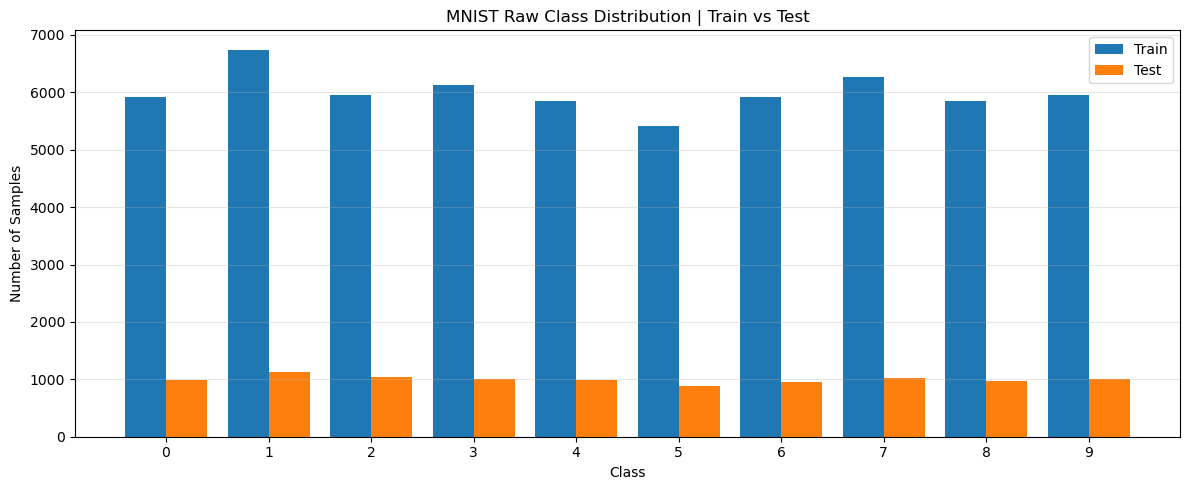

In [6]:
# This cell plots the raw class distribution for MNIST train and test splits.
# It helps verify that the digit classes are reasonably balanced across both splits.
# The same distribution helper will be reused for the later datasets as well.
mnist_train_counts = Counter(train_dataset.targets.tolist())
mnist_test_counts = Counter(test_dataset.targets.tolist())

plot_class_distribution(
    split_names=["Train", "Test"],
    split_counts=[
        [mnist_train_counts[label] for label in range(10)],
        [mnist_test_counts[label] for label in range(10)],
    ],
    class_labels=class_names,
    title="MNIST Raw Class Distribution | Train vs Test",
)


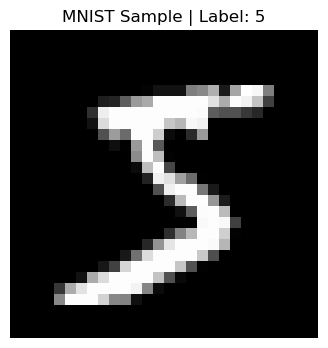

In [7]:
# This cell displays one raw MNIST image from the training set.
# It provides a direct visual check of the grayscale image and its label.
# This is the simplest form of sample-level MNIST inspection.
sample_index = 0
image, label = train_dataset[sample_index]

plt.figure(figsize=(4, 4))
plt.imshow(image, cmap="gray")
plt.title(f"MNIST Sample | Label: {label}")
plt.axis("off")
plt.show()


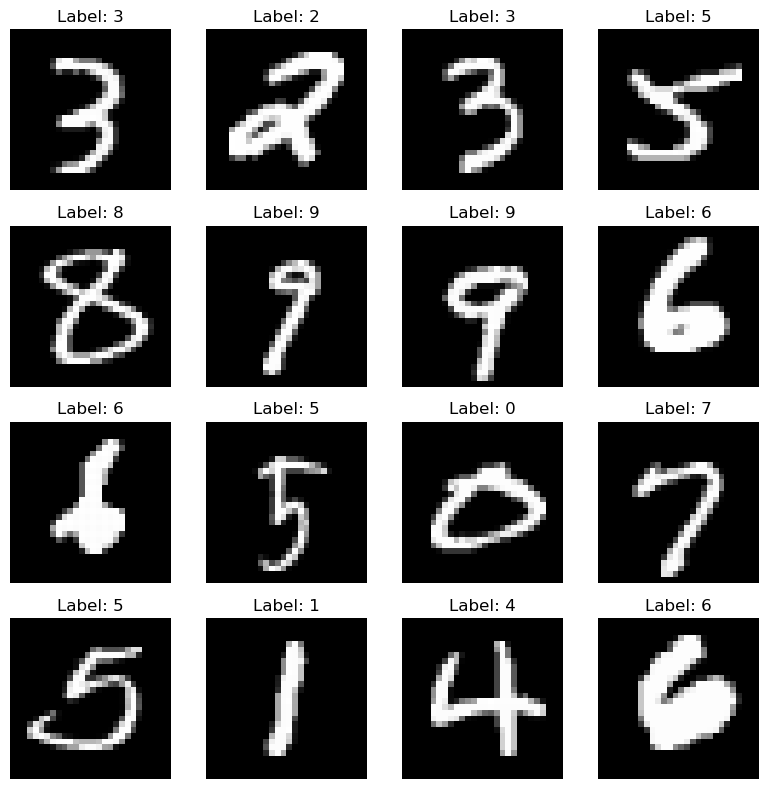

In [8]:
# This cell shows a random grid of raw MNIST training samples.
# Viewing multiple digits together helps inspect class variety and writing style differences.
# The images remain untransformed and are shown exactly as loaded.
num_images = 16
random_indices = random.sample(range(len(train_dataset)), num_images)

fig, axes = plt.subplots(4, 4, figsize=(8, 8))

for ax, idx in zip(axes.flatten(), random_indices):
    image, label = train_dataset[idx]
    ax.imshow(image, cmap="gray")
    ax.set_title(f"Label: {label}")
    ax.axis("off")

plt.tight_layout()
plt.show()


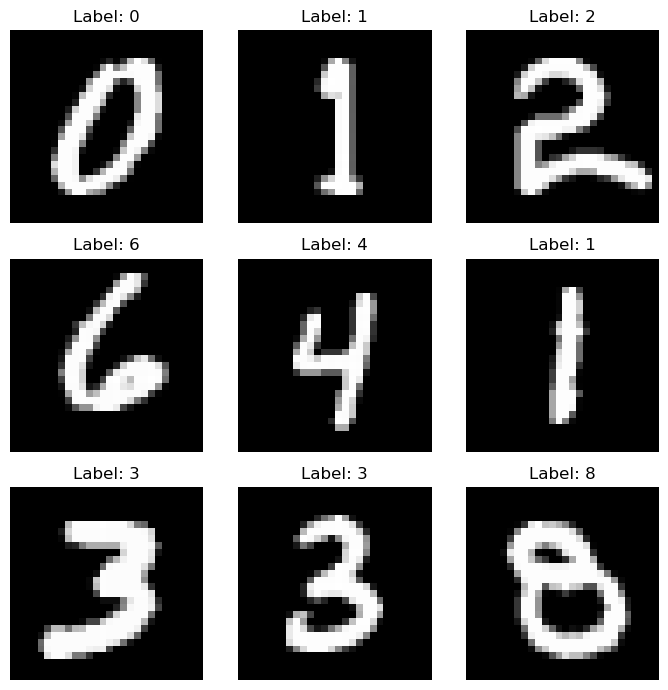

In [9]:
# This cell shows a random grid of raw MNIST test samples.
# It allows comparison of the unseen test split with the training examples.
# The goal is to verify the raw test data before any preprocessing.
num_test_images = 9
test_indices = random.sample(range(len(test_dataset)), num_test_images)

fig, axes = plt.subplots(3, 3, figsize=(7, 7))

for ax, idx in zip(axes.flatten(), test_indices):
    image, label = test_dataset[idx]
    ax.imshow(image, cmap="gray")
    ax.set_title(f"Label: {label}")
    ax.axis("off")

plt.tight_layout()
plt.show()


# C-MNIST
Raw dataset loading, class inspection, split distribution check, and image visualization for Colored-MNIST.

In [10]:
# This cell imports torch and loads the raw C-MNIST tensor files from disk.
# It brings in the biased train split along with biased and unbiased test splits.
# The tensors are loaded onto CPU so they can be inspected safely.
import torch

cmnist_root = "./cmnist"

train_biased_images, train_biased_labels = torch.load(f"{cmnist_root}/train_biased.pt", map_location="cpu")
test_biased_images, test_biased_labels = torch.load(f"{cmnist_root}/test_biased.pt", map_location="cpu")
test_unbiased_images, test_unbiased_labels = torch.load(f"{cmnist_root}/test_unbiased.pt", map_location="cpu")

print("C-MNIST raw files loaded successfully.")


/tmp/ipykernel_72339/903320082.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  train_biased_images, train_biased_labels = torch.load(f"{cmnist_root}/train_biased.pt", ma

C-MNIST raw files loaded successfully.


/tmp/ipykernel_72339/903320082.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  test_biased_images, test_biased_labels = torch.load(f"{cmnist_root}/test_biased.pt", map_l

In [11]:
# This cell prints the raw tensor shapes, label shapes, dtypes, and pixel ranges for C-MNIST.
# It checks all three splits so the stored format is clear before visualization.
# This helps confirm whether the images are RGB and what value range they use.
print("Train biased image shape:", train_biased_images.shape)
print("Train biased label shape:", train_biased_labels.shape)
print("Train biased dtype:", train_biased_images.dtype)
print("Train biased pixel range:", (train_biased_images.min().item(), train_biased_images.max().item()))
print()
print("Test biased image shape:", test_biased_images.shape)
print("Test biased label shape:", test_biased_labels.shape)
print("Test biased dtype:", test_biased_images.dtype)
print("Test biased pixel range:", (test_biased_images.min().item(), test_biased_images.max().item()))
print()
print("Test unbiased image shape:", test_unbiased_images.shape)
print("Test unbiased label shape:", test_unbiased_labels.shape)
print("Test unbiased dtype:", test_unbiased_images.dtype)
print("Test unbiased pixel range:", (test_unbiased_images.min().item(), test_unbiased_images.max().item()))


Train biased image shape: torch.Size([60000, 3, 28, 28])
Train biased label shape: torch.Size([60000])
Train biased dtype: torch.float32
Train biased pixel range: (0.0, 1.0)

Test biased image shape: torch.Size([10000, 3, 28, 28])
Test biased label shape: torch.Size([10000])
Test biased dtype: torch.float32
Test biased pixel range: (0.0, 1.0)

Test unbiased image shape: torch.Size([10000, 3, 28, 28])
Test unbiased label shape: torch.Size([10000])
Test unbiased dtype: torch.float32
Test unbiased pixel range: (0.0, 1.0)


In [12]:
# This cell lists the C-MNIST classes and counts labels in each split.
# It compares train-biased, test-biased, and test-unbiased label frequencies.
# These counts are later used both for reporting and for the distribution chart.
cmnist_classes = sorted(train_biased_labels.unique().tolist())
print("C-MNIST classes:", cmnist_classes)
print("Class names:", [class_names[label] for label in cmnist_classes])
print()

train_biased_counts = Counter(train_biased_labels.tolist())
test_biased_counts = Counter(test_biased_labels.tolist())
test_unbiased_counts = Counter(test_unbiased_labels.tolist())

print("Train biased label counts:")
for label in cmnist_classes:
    print(f"Digit {label}: {train_biased_counts[label]} images")

print()
print("Test biased label counts:")
for label in cmnist_classes:
    print(f"Digit {label}: {test_biased_counts[label]} images")

print()
print("Test unbiased label counts:")
for label in cmnist_classes:
    print(f"Digit {label}: {test_unbiased_counts[label]} images")


C-MNIST classes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Class names: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']

Train biased label counts:
Digit 0: 5923 images
Digit 1: 6742 images
Digit 2: 5958 images
Digit 3: 6131 images
Digit 4: 5842 images
Digit 5: 5421 images
Digit 6: 5918 images
Digit 7: 6265 images
Digit 8: 5851 images
Digit 9: 5949 images

Test biased label counts:
Digit 0: 980 images
Digit 1: 1135 images
Digit 2: 1032 images
Digit 3: 1010 images
Digit 4: 982 images
Digit 5: 892 images
Digit 6: 958 images
Digit 7: 1028 images
Digit 8: 974 images
Digit 9: 1009 images

Test unbiased label counts:
Digit 0: 980 images
Digit 1: 1135 images
Digit 2: 1032 images
Digit 3: 1010 images
Digit 4: 982 images
Digit 5: 892 images
Digit 6: 958 images
Digit 7: 1028 images
Digit 8: 974 images
Digit 9: 1009 images


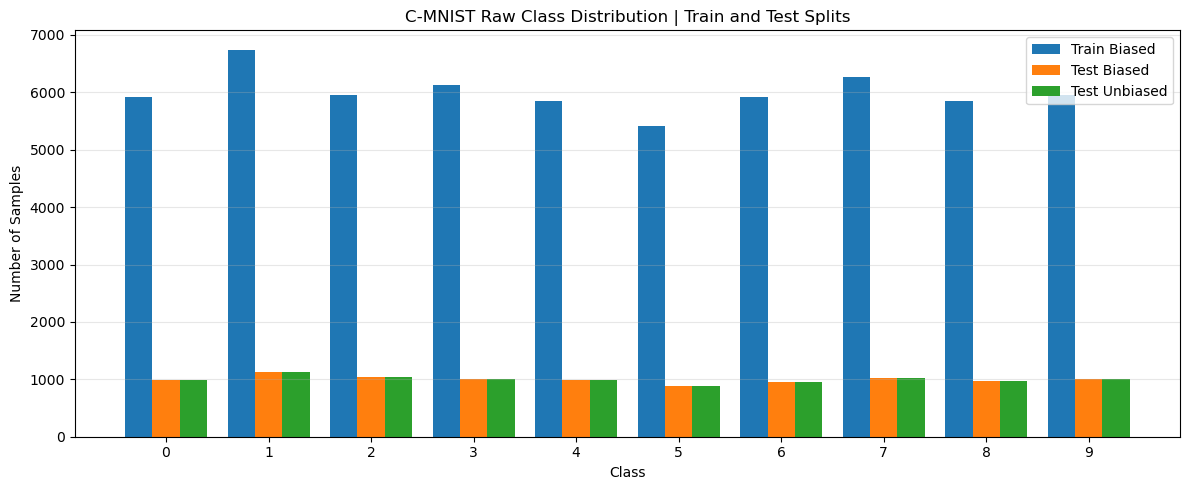

In [13]:
# This cell plots the raw class-count distribution across all C-MNIST splits.
# It visually compares the train-biased, test-biased, and test-unbiased datasets.
# This makes any split-level balance or imbalance easier to inspect.
plot_class_distribution(
    split_names=["Train Biased", "Test Biased", "Test Unbiased"],
    split_counts=[
        [train_biased_counts[label] for label in cmnist_classes],
        [test_biased_counts[label] for label in cmnist_classes],
        [test_unbiased_counts[label] for label in cmnist_classes],
    ],
    class_labels=[str(label) for label in cmnist_classes],
    title="C-MNIST Raw Class Distribution | Train and Test Splits",
)


In [14]:
# This cell defines helpers for preparing and visualizing raw C-MNIST images.
# The image helper converts tensors into displayable RGB arrays while preserving raw content.
# The sample viewer is reused for train-biased, test-biased, and test-unbiased visual grids.
def prepare_cmnist_image(image_tensor):
    image = image_tensor.detach().cpu()

    if image.ndim == 3 and image.shape[0] == 3:
        image = image.permute(1, 2, 0)

    if torch.is_floating_point(image):
        if image.max().item() > 1:
            image = image / 255.0
        image = image.clamp(0, 1)

    return image.numpy()


def show_random_cmnist_samples(images, labels, title, num_images=9, cols=3):
    random_indices = random.sample(range(len(images)), num_images)
    rows = int(np.ceil(num_images / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = np.array(axes).reshape(rows, cols)

    for ax, idx in zip(axes.flatten(), random_indices):
        image = prepare_cmnist_image(images[idx])
        label = labels[idx].item()
        ax.imshow(image)
        ax.set_title(f"Label: {label}")
        ax.axis("off")

    for ax in axes.flatten()[num_images:]:
        ax.axis("off")

    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()


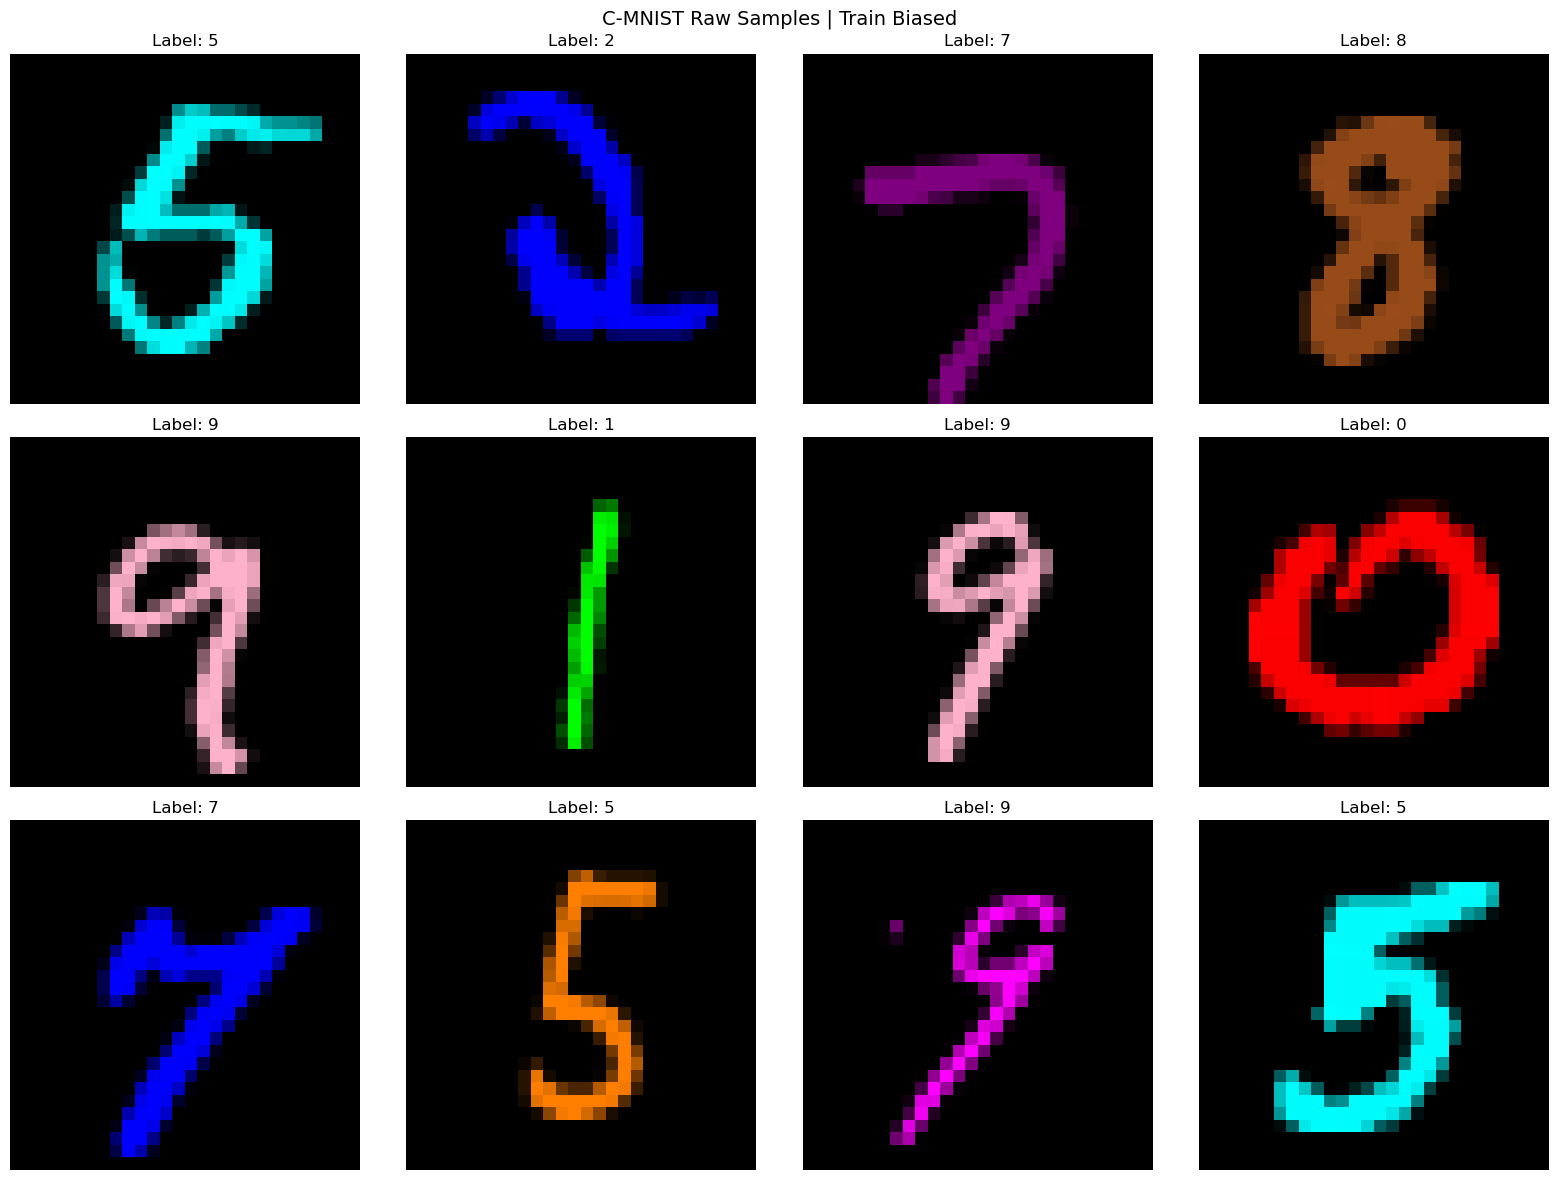

In [15]:
# This cell displays a random set of raw C-MNIST images from the biased training split.
# It helps inspect how colors and digit shapes appear in the main training data.
# The samples are shown without model preprocessing or normalization.
show_random_cmnist_samples(
    train_biased_images,
    train_biased_labels,
    title="C-MNIST Raw Samples | Train Biased",
    num_images=12,
    cols=4,
)


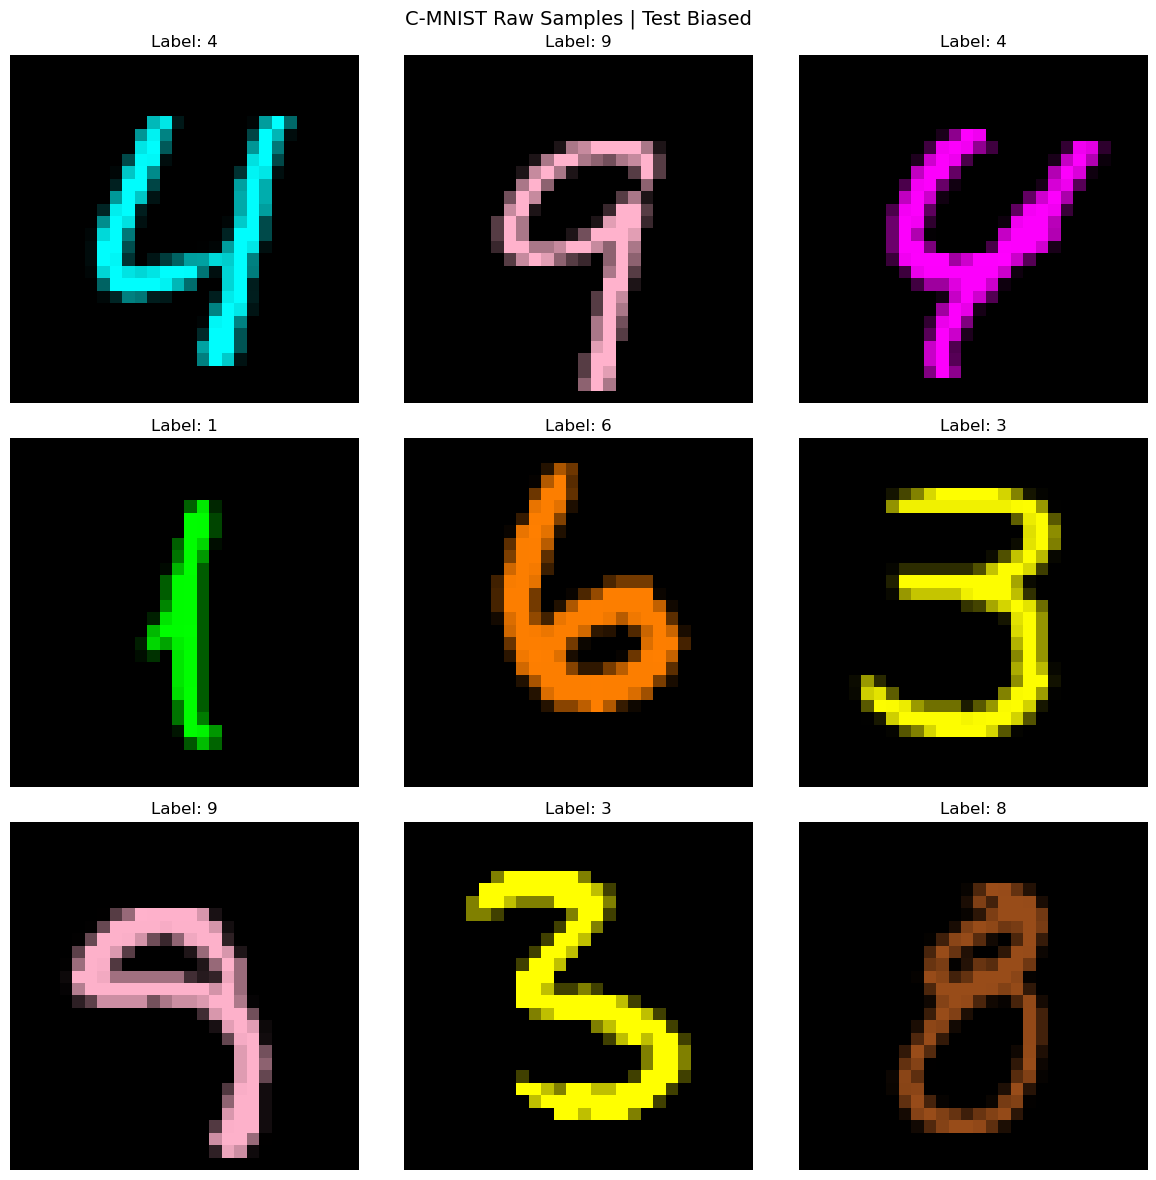

In [16]:
# This cell displays random raw images from the biased C-MNIST test split.
# It allows visual comparison between the biased training data and the biased test data.
# This is useful before analyzing model performance on the shortcut distribution.
show_random_cmnist_samples(
    test_biased_images,
    test_biased_labels,
    title="C-MNIST Raw Samples | Test Biased",
    num_images=9,
    cols=3,
)


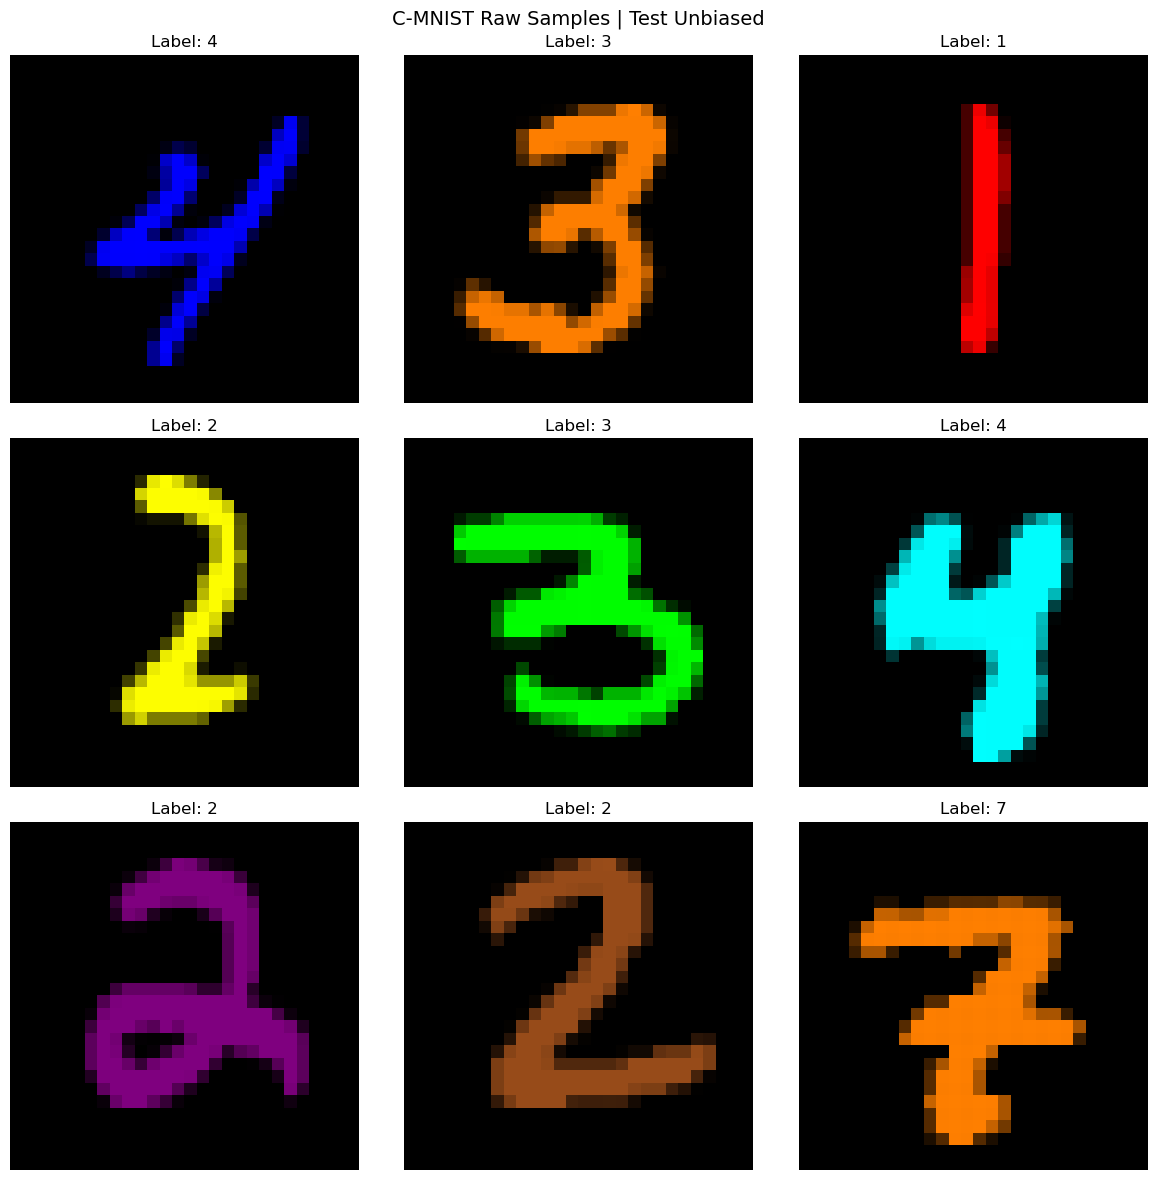

In [17]:
# This cell displays random raw images from the unbiased C-MNIST test split.
# It helps inspect how the unbiased evaluation data differs visually from the biased splits.
# This section is important for understanding the later generalization gap.
show_random_cmnist_samples(
    test_unbiased_images,
    test_unbiased_labels,
    title="C-MNIST Raw Samples | Test Unbiased",
    num_images=9,
    cols=3,
)


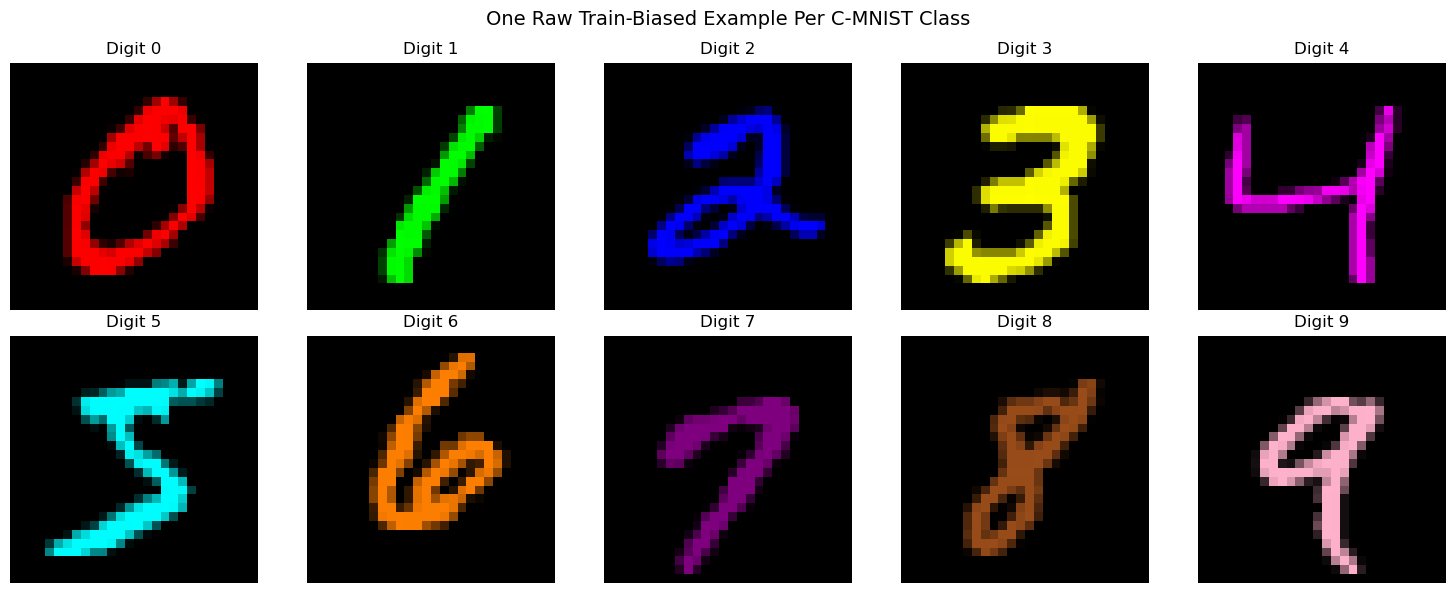

In [18]:
# This cell shows one raw C-MNIST training example for each digit class.
# It provides a compact class-wise overview of the colored dataset.
# Seeing one sample per class helps relate labels to the raw images directly.
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for ax, label in zip(axes.flatten(), cmnist_classes):
    class_index = (train_biased_labels == label).nonzero(as_tuple=True)[0][0].item()
    class_image = prepare_cmnist_image(train_biased_images[class_index])
    ax.imshow(class_image)
    ax.set_title(f"Digit {label}")
    ax.axis("off")

plt.suptitle("One Raw Train-Biased Example Per C-MNIST Class", fontsize=14)
plt.tight_layout()
plt.show()


# STL-10
Raw dataset loading, class inspection, distribution check, and image visualization for STL-10.

In [19]:
# This cell defines the STL-10 path, class names, and loads the raw train and test splits.
# The images are kept in raw PIL format so they can be explored before resizing or normalization.
# It also prints split sizes and class names for quick verification.
stl10_data_root = "./stl10_data"
stl10_class_names = [
    "airplane",
    "bird",
    "car",
    "cat",
    "deer",
    "dog",
    "horse",
    "monkey",
    "ship",
    "truck",
]

stl10_train_dataset = datasets.STL10(
    root=stl10_data_root,
    split="train",
    download=True,
)

stl10_test_dataset = datasets.STL10(
    root=stl10_data_root,
    split="test",
    download=True,
)

print("STL-10 data will be stored in:", stl10_data_root)
print("STL-10 training samples:", len(stl10_train_dataset))
print("STL-10 test samples:", len(stl10_test_dataset))
print("STL-10 classes:", stl10_class_names)


Files already downloaded and verified
Files already downloaded and verified
STL-10 data will be stored in: ./stl10_data
STL-10 training samples: 5000
STL-10 test samples: 8000
STL-10 classes: ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']


In [20]:
# This cell inspects one raw STL-10 training example and the split label counts.
# It reports image metadata such as size, mode, pixel range, and the corresponding class name.
# It also summarizes how many samples each class has in train and test.
stl10_sample_image, stl10_sample_label = stl10_train_dataset[0]

print("Image type:", type(stl10_sample_image))
print("Image size (width, height):", stl10_sample_image.size)
print("Image mode:", stl10_sample_image.mode)
print("Pixel range:", stl10_sample_image.getextrema())
print("Sample label:", stl10_sample_label)
print("Class name:", stl10_class_names[stl10_sample_label])
print()

stl10_train_counts = Counter(stl10_train_dataset.labels.tolist())
stl10_test_counts = Counter(stl10_test_dataset.labels.tolist())

print("STL-10 train label counts:")
for label in range(10):
    print(f"{stl10_class_names[label]}: {stl10_train_counts[label]} images")

print()
print("STL-10 test label counts:")
for label in range(10):
    print(f"{stl10_class_names[label]}: {stl10_test_counts[label]} images")


Image type: <class 'PIL.Image.Image'>
Image size (width, height): (96, 96)
Image mode: RGB
Pixel range: ((0, 255), (0, 255), (0, 212))
Sample label: 1
Class name: bird

STL-10 train label counts:
airplane: 500 images
bird: 500 images
car: 500 images
cat: 500 images
deer: 500 images
dog: 500 images
horse: 500 images
monkey: 500 images
ship: 500 images
truck: 500 images

STL-10 test label counts:
airplane: 800 images
bird: 800 images
car: 800 images
cat: 800 images
deer: 800 images
dog: 800 images
horse: 800 images
monkey: 800 images
ship: 800 images
truck: 800 images


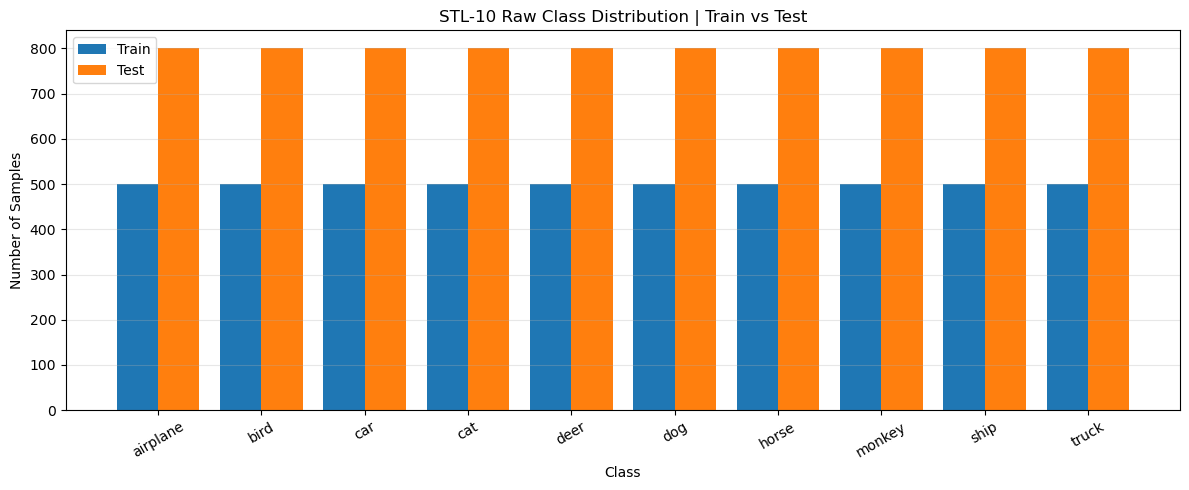

In [21]:
# This cell plots the raw STL-10 class distribution for train and test splits.
# It helps verify whether the class frequencies are balanced before modeling.
# The labels are shown using the human-readable STL-10 class names.
plot_class_distribution(
    split_names=["Train", "Test"],
    split_counts=[
        [stl10_train_counts[label] for label in range(10)],
        [stl10_test_counts[label] for label in range(10)],
    ],
    class_labels=stl10_class_names,
    title="STL-10 Raw Class Distribution | Train vs Test",
)


In [22]:
# This cell defines a helper to visualize random raw STL-10 samples in a grid.
# It works directly on the raw dataset objects and displays the class name above each image.
# The helper is reused for both training and test exploration below.
def show_random_stl10_samples(dataset, title, num_images=9, cols=3):
    random_indices = random.sample(range(len(dataset)), num_images)
    rows = int(np.ceil(num_images / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = np.array(axes).reshape(rows, cols)

    for ax, idx in zip(axes.flatten(), random_indices):
        image, label = dataset[idx]
        ax.imshow(image)
        ax.set_title(f"{stl10_class_names[label]}")
        ax.axis("off")

    for ax in axes.flatten()[num_images:]:
        ax.axis("off")

    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()


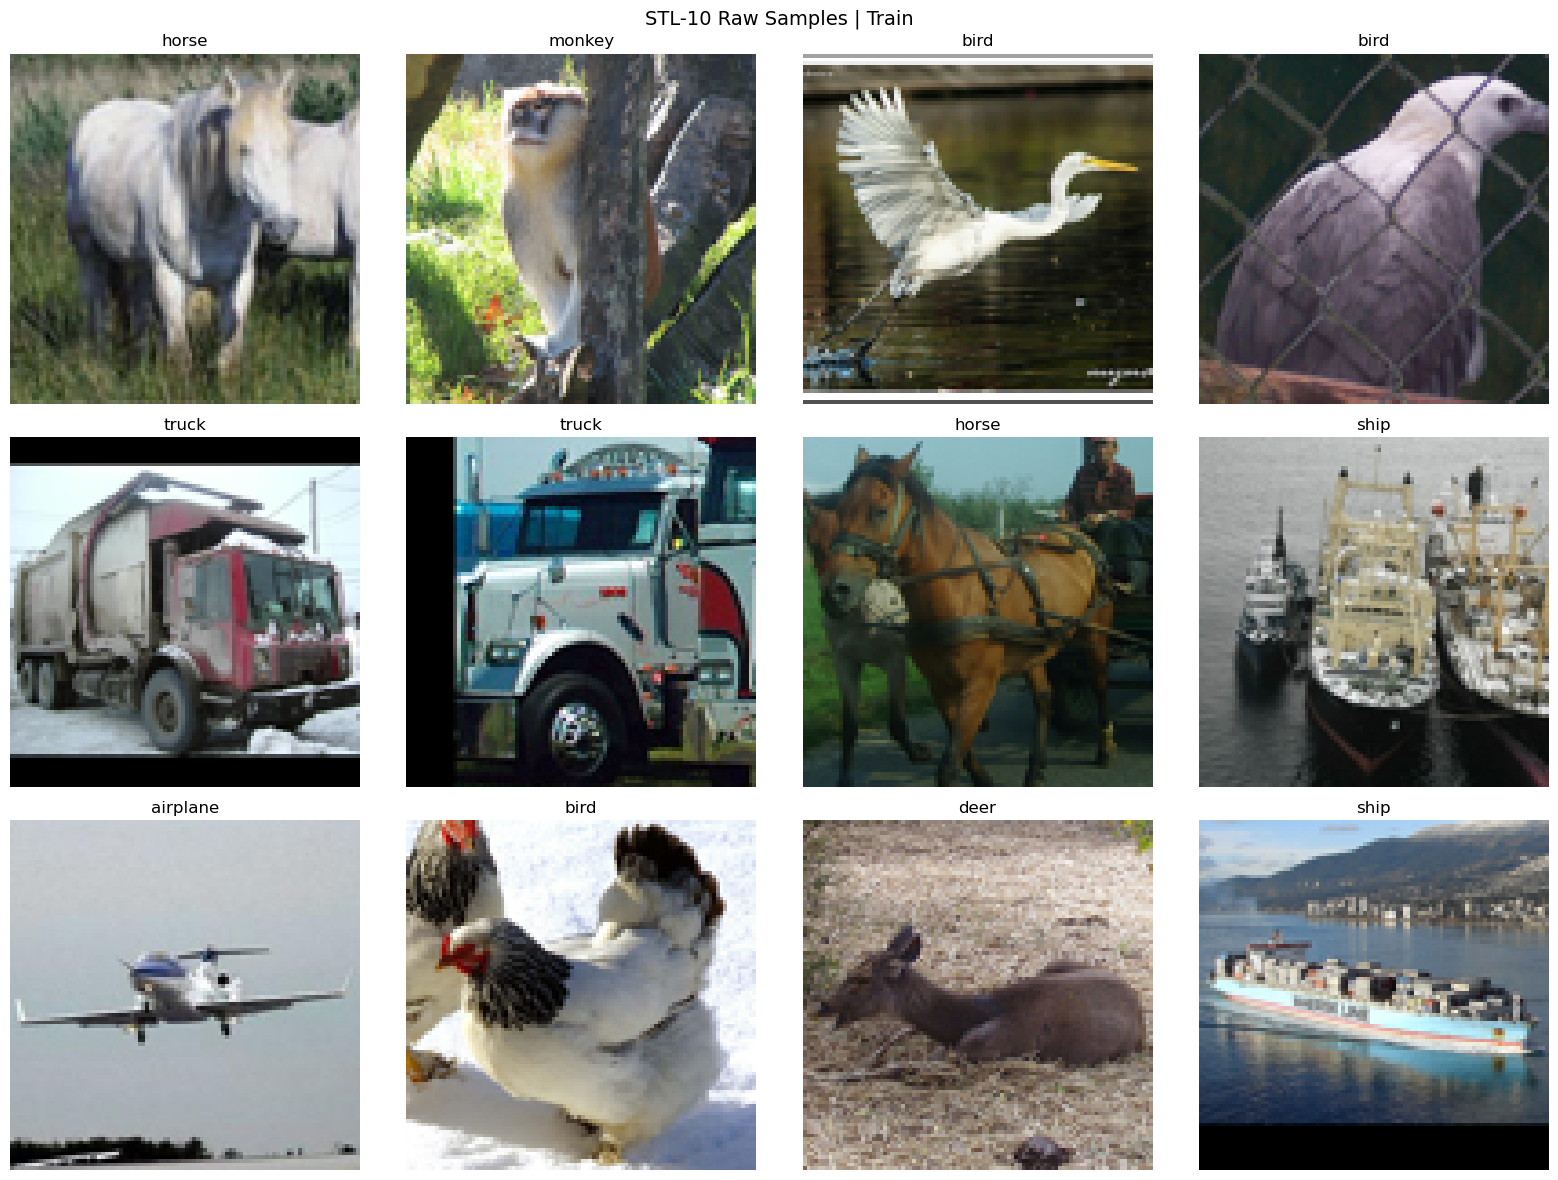

In [23]:
# This cell shows a random set of raw STL-10 images from the training split.
# It is useful for visually checking object variety, backgrounds, and image quality.
# The samples are displayed before any model-specific preprocessing is applied.
show_random_stl10_samples(
    stl10_train_dataset,
    title="STL-10 Raw Samples | Train",
    num_images=12,
    cols=4,
)


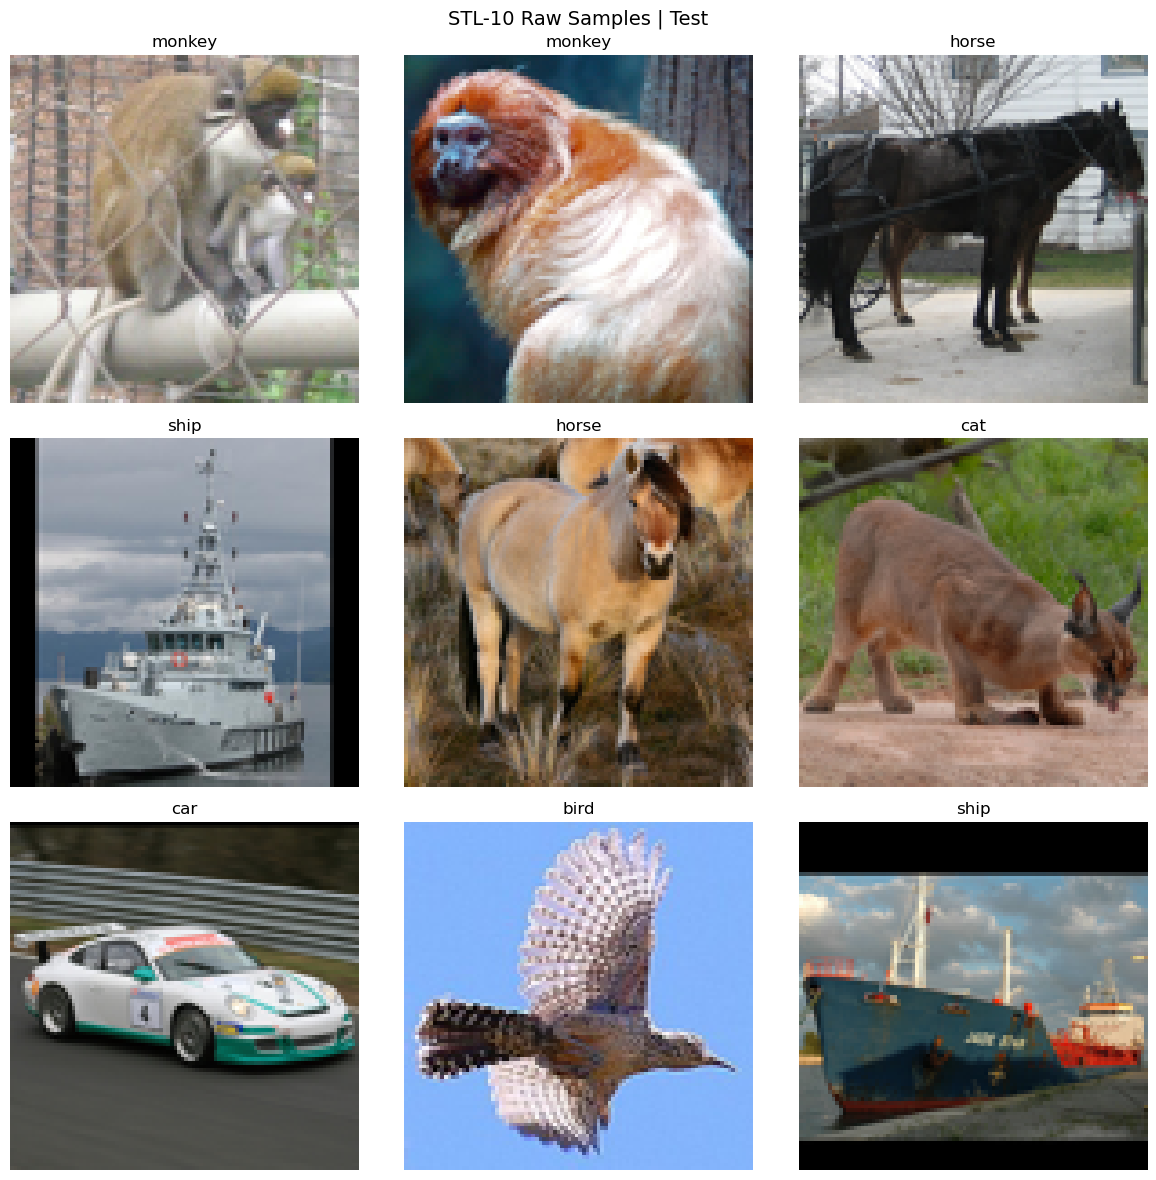

In [24]:
# This cell shows a random set of raw STL-10 images from the test split.
# It gives a quick visual comparison with the raw training images.
# This helps confirm the evaluation data format before transfer learning.
show_random_stl10_samples(
    stl10_test_dataset,
    title="STL-10 Raw Samples | Test",
    num_images=9,
    cols=3,
)


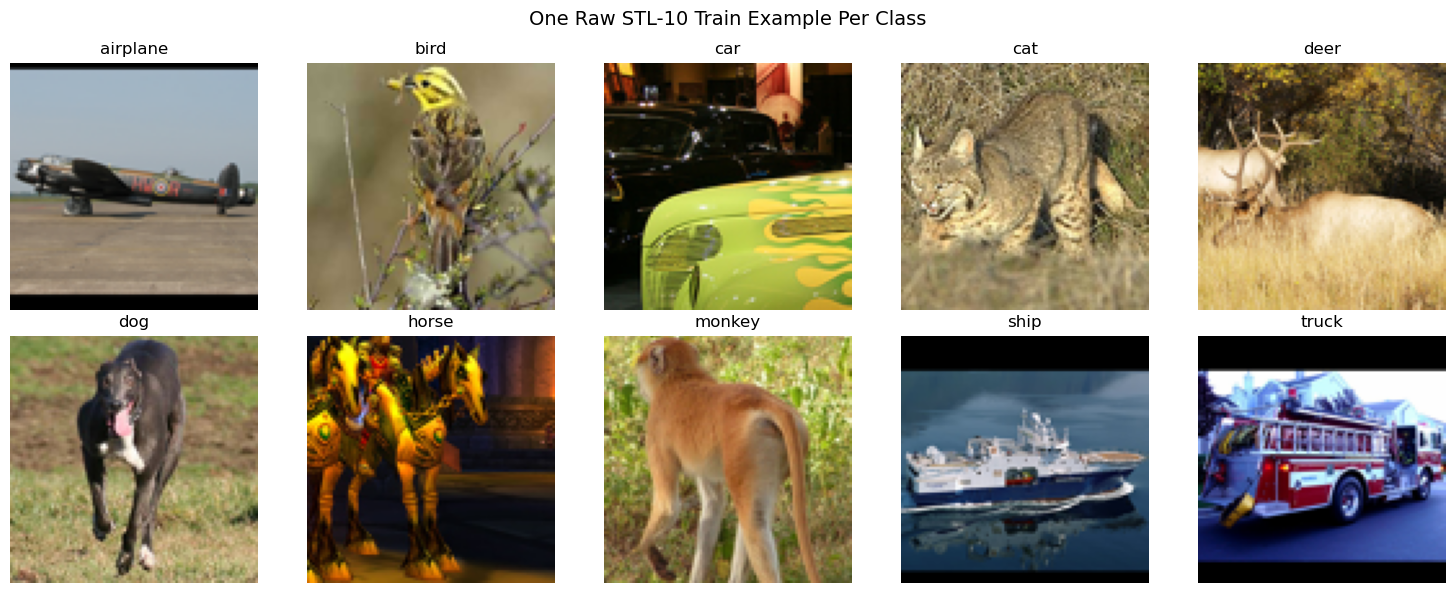

In [25]:
# This cell shows one raw STL-10 training example for each class.
# It creates a compact class-wise overview of the dataset using human-readable labels.
# This is useful for summarizing the object categories present in STL-10.
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for ax, label in zip(axes.flatten(), range(10)):
    class_index = np.where(np.array(stl10_train_dataset.labels) == label)[0][0]
    class_image, _ = stl10_train_dataset[class_index]
    ax.imshow(class_image)
    ax.set_title(stl10_class_names[label])
    ax.axis("off")

plt.suptitle("One Raw STL-10 Train Example Per Class", fontsize=14)
plt.tight_layout()
plt.show()
